# Fish Movement Simulator

Simulates one round of fish movement in the Trout Derby pond, visualizing each fish's color-coded path.

**Workflow:**
1. Edit parameters in the **Configuration** cell
2. Run all cells to simulate and visualize
3. Tune parameters and repeat until the movement feels right

The simulation mirrors the design in `fish-behavior.md`:
- Each fish has a random tick interval assigned at spawn
- Each tick: fish turns by a random amount, then moves forward
- Anti-crowding: fish push away from each other when too close
- Boundary enforcement: fish stay within the pond polygon

> **Godot vs. Notebook:** This notebook is for design-time parameter exploration.
> The movement logic mirrors what you'll implement in GDScript, so tuned values transfer
> directly. Godot gives you real-time feel but is harder to instrument for bulk analysis.
> Use this notebook to converge on good parameters, then port them.


In [28]:
import heapq
import json
import math
import os
import random

from matplotlib.collections import LineCollection

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

## Configuration

All tweakable parameters. Re-run all cells after changing any value.


In [29]:
# ── Simulation ────────────────────────────────────────────────────────────────
RANDOM_SEED        = 42       # Seed for reproducibility; set to None for a new result each run
ROUND_DURATION_S   = 300      # Seconds to simulate (5 minutes = 300 s)
FISH_COUNT         = 120      # Fish to simulate. Tuning here shows 50 might be too small for the pace we're looking for. 120 tries to balance performance with action for all players

# ── Movement (mirrors fish-behavior.md) ───────────────────────────────────────
MOVE_DIST_MIN_M    = 0.3      # Minimum distance traveled per movement tick (meters)
MOVE_DIST_MAX_M    = 1.0      # Maximum distance traveled per movement tick (meters)
TURN_ANGLE_MAX_DEG = 110      # Max heading change per tick (degrees, ±relative to current heading)
TICK_MIN_S         = 5        # Fastest tick interval — most active fish (seconds)
TICK_MAX_S         = 45       # Slowest tick interval — laziest fish (seconds)

# ── Anti-crowding ─────────────────────────────────────────────────────────────
ENABLE_ANTICROWDING  = True   # Toggle fish repulsion behavior on/off
REPULSION_RADIUS_M   = 2.0    # Fish within this distance push each other away (meters)
REPULSION_STRENGTH   = 0.5    # Repulsion influence: 0.0 = none, 1.0 = strong

# ── Boundary handling ─────────────────────────────────────────────────────────
MAX_BOUNDARY_RETRIES = 20     # Attempts to find a valid in-bounds heading before staying put

# ── World scale (should match pond_editor.ipynb) ──────────────────────────────
PIXELS_PER_METER = 15         # 15 px = 1 m
CANVAS_W         = 1280       # pixels
CANVAS_H         = 720        # pixels


## Load Pond & Helpers

Loads pond vertices from `project/data/pond_data.json` (written by pond_editor.ipynb).
Falls back to hardcoded vertices if the file hasn't been exported yet.


In [30]:
# ── Load pond vertices ────────────────────────────────────────────────────────
# In Jupyter, __file__ is not defined; os.getcwd() returns the notebook directory.
_project_root = os.path.normpath(os.path.join(os.getcwd(), "..", ".."))
_json_path    = os.path.join(_project_root, "project", "data", "pond_data.json")
_json_rel     = os.path.relpath(_json_path, _project_root)  # e.g. project/data/pond_data.json

if os.path.exists(_json_path):
    with open(_json_path, encoding="utf-8") as f:
        _pond = json.load(f)
    VERTICES         = _pond["vertices"]
    PIXELS_PER_METER = _pond["meta"].get("pixels_per_meter", PIXELS_PER_METER)
    print(f"Loaded {len(VERTICES)} vertices from {_json_rel}")
else:
    print(f"pond_data.json not found at {_json_rel} — using hardcoded fallback vertices")
    VERTICES = [
        [565, 150], [750, 180], [925, 165], [910, 275],
        [925, 380], [880, 500], [800, 600], [645, 650],
        [515, 530], [375, 520], [390, 275],
    ]


# ── Geometry helpers ──────────────────────────────────────────────────────────
def point_in_polygon(px, py, verts):
    """Ray-casting point-in-polygon test. Returns True if (px, py) is inside."""
    n, inside = len(verts), False
    j = n - 1
    for i in range(n):
        xi, yi = verts[i]
        xj, yj = verts[j]
        if ((yi > py) != (yj > py)) and (px < (xj - xi) * (py - yi) / (yj - yi) + xi):
            inside = not inside
        j = i
    return inside


def random_point_in_polygon(verts, rng):
    """Rejection-sample a uniformly random point inside the polygon."""
    xs = [v[0] for v in verts]
    ys = [v[1] for v in verts]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    while True:
        px = rng.uniform(xmin, xmax)
        py = rng.uniform(ymin, ymax)
        if point_in_polygon(px, py, verts):
            return [px, py]


def compute_centroid(verts):
    """Centroid of a polygon using the weighted shoelace formula."""
    n = len(verts)
    cx = cy = area_signed = 0.0
    for i in range(n):
        x0, y0 = verts[i]
        x1, y1 = verts[(i + 1) % n]
        cross = x0 * y1 - x1 * y0
        area_signed += cross
        cx += (x0 + x1) * cross
        cy += (y0 + y1) * cross
    area_signed *= 0.5
    cx /= 6 * area_signed
    cy /= 6 * area_signed

    return cx, cy

Loaded 11 vertices from project\data\pond_data.json


In [31]:
# ── Load fish pool ────────────────────────────────────────────────────────────
# Sample movement_tick_interval from fish_pool.csv (standard fish only).
# Fish are sampled with replacement, so FISH_COUNT can exceed the pool size.
# Falls back to None → uniform(TICK_MIN_S, TICK_MAX_S) if the file isn't found.
_csv_path = os.path.join(_project_root, "tools", "fish_pool.csv")
_csv_rel  = os.path.relpath(_csv_path, _project_root)

if os.path.exists(_csv_path):
    _pool_df  = pd.read_csv(_csv_path)
    _std      = _pool_df[_pool_df["is_trophy"] == False]
    TICK_POOL = _std["movement_tick_interval"].tolist()
    print(f"Loaded {len(TICK_POOL)} standard fish from {_csv_rel}")
    print(f"  Tick interval — min {min(TICK_POOL):.1f}s  max {max(TICK_POOL):.1f}s  "
          f"mean {sum(TICK_POOL)/len(TICK_POOL):.1f}s")
else:
    TICK_POOL = None
    print(f"fish_pool.csv not found at {_csv_rel} — will fall back to uniform({TICK_MIN_S}, {TICK_MAX_S})")


Loaded 120 standard fish from tools\fish_pool.csv
  Tick interval — min 4.7s  max 30.0s  mean 17.8s


## Simulate

Runs a round using an event-driven approach: each fish has its own independent timer.
First ticks are staggered randomly within `[0, tick_interval]` so fish don't all lurch
at `t=0`.

Each movement tick:
1. Fish picks a new heading: current heading ± random turn within `TURN_ANGLE_MAX_DEG`
2. If `ENABLE_ANTICROWDING`, nearby fish push the heading away from them
3. Fish steps forward by a random distance in `[MOVE_DIST_MIN_M, MOVE_DIST_MAX_M]`
4. If the new position is outside the pond, up to `MAX_BOUNDARY_RETRIES` random headings are tried before skipping the tick


In [32]:
def simulate_round(vertices, config):
    """
    Simulate one round of fish movement.

    Returns a list of fish dicts, each containing:
      - 'id'         : fish index
      - 'tick_iv'    : assigned tick interval (seconds)
      - 'path'       : [[x, y], ...] positions at each movement tick (including spawn)
      - 'tick_times' : simulation time (s) of each path entry
    """
    rng            = random.Random(config["seed"])
    ppm            = config["pixels_per_meter"]
    duration       = config["round_duration_s"]
    count          = config["fish_count"]
    repulsion_r_px = config["repulsion_radius_m"] * ppm
    turn_max_rad   = math.radians(config["turn_angle_max_deg"])
    move_min_px    = config["move_dist_min_m"] * ppm
    move_max_px    = config["move_dist_max_m"] * ppm
    tick_pool      = config.get("tick_pool")  # list of real tick intervals, or None

    # ── Spawn fish at random positions inside the pond ─────────────────────────
    fish = []
    for i in range(count):
        pos     = random_point_in_polygon(vertices, rng)
        heading = rng.uniform(0, 2 * math.pi)
        # Sample tick interval from the real fish pool (with replacement),
        # or fall back to uniform if the pool isn't available.
        tick_iv = (rng.choice(tick_pool) if tick_pool
                   else rng.uniform(config["tick_min_s"], config["tick_max_s"]))
        fish.append({
            "id":         i,
            "pos":        pos[:],
            "heading":    heading,
            "tick_iv":    tick_iv,
            "path":       [pos[:]],
            "tick_times": [0.0],
        })

    # ── Event queue: (scheduled_time, fish_id) ────────────────────────────────
    events = []
    for f in fish:
        first_tick = rng.uniform(0, f["tick_iv"])   # stagger so fish don't all move at t=0
        heapq.heappush(events, (first_tick, f["id"]))

    # ── Process events until end of round ─────────────────────────────────────
    while events:
        t, fid = heapq.heappop(events)
        if t > duration:
            break

        f       = fish[fid]
        move_px = rng.uniform(move_min_px, move_max_px)
        turn    = rng.uniform(-turn_max_rad, turn_max_rad)
        new_hdg = f["heading"] + turn

        # Optional anti-crowding: nudge heading away from nearby fish
        if config["enable_anticrowding"]:
            rep_x = rep_y = 0.0
            for other in fish:
                if other["id"] == fid:
                    continue
                dx = f["pos"][0] - other["pos"][0]
                dy = f["pos"][1] - other["pos"][1]
                d  = math.hypot(dx, dy)
                if 0 < d < repulsion_r_px:
                    w      = 1.0 - d / repulsion_r_px   # linear falloff: strongest up close
                    rep_x += (dx / d) * w
                    rep_y += (dy / d) * w
            strength = config["repulsion_strength"]
            dx_d    = math.cos(new_hdg) + rep_x * strength
            dy_d    = math.sin(new_hdg) + rep_y * strength
            new_hdg = math.atan2(dy_d, dx_d)

        # Try to move; if out of bounds, retry with random headings
        for attempt in range(config["max_boundary_retries"] + 1):
            hdg_try = new_hdg if attempt == 0 else rng.uniform(0, 2 * math.pi)
            nx = f["pos"][0] + math.cos(hdg_try) * move_px
            ny = f["pos"][1] + math.sin(hdg_try) * move_px
            if point_in_polygon(nx, ny, vertices):
                f["pos"]     = [nx, ny]
                f["heading"] = hdg_try
                f["path"].append(f["pos"][:])
                f["tick_times"].append(t)
                break
        # If no valid heading found in all retries, fish stays put this tick

        # Schedule next tick
        next_t = t + f["tick_iv"]
        if next_t <= duration:
            heapq.heappush(events, (next_t, fid))

    return fish


# ── Run ───────────────────────────────────────────────────────────────────────
SIM_CONFIG = {
    "seed":                  RANDOM_SEED,
    "round_duration_s":      ROUND_DURATION_S,
    "fish_count":            FISH_COUNT,
    "move_dist_min_m":       MOVE_DIST_MIN_M,
    "move_dist_max_m":       MOVE_DIST_MAX_M,
    "turn_angle_max_deg":    TURN_ANGLE_MAX_DEG,
    "tick_min_s":            TICK_MIN_S,
    "tick_max_s":            TICK_MAX_S,
    "tick_pool":             TICK_POOL,       # None → falls back to uniform
    "enable_anticrowding":   ENABLE_ANTICROWDING,
    "repulsion_radius_m":    REPULSION_RADIUS_M,
    "repulsion_strength":    REPULSION_STRENGTH,
    "max_boundary_retries":  MAX_BOUNDARY_RETRIES,
    "pixels_per_meter":      PIXELS_PER_METER,
}

fish_results = simulate_round(VERTICES, SIM_CONFIG)

total_ticks = sum(len(f["path"]) - 1 for f in fish_results)
pool_note   = (f"sampled from {len(TICK_POOL)}-fish pool" if TICK_POOL
               else f"uniform tick ({TICK_MIN_S}–{TICK_MAX_S}s)")
print(f"Simulated {len(fish_results)} fish over {ROUND_DURATION_S}s  ({pool_note})")
print(f"Total movement ticks: {total_ticks}  (avg {total_ticks / len(fish_results):.1f} per fish)")


Simulated 120 fish over 300s  (sampled from 120-fish pool)
Total movement ticks: 2269  (avg 18.9 per fish)


## Visualize Paths

Color-coded movement paths for all fish over the simulated round.

- **○** = spawn position  
- **×** = final position  
- **·** = intermediate movement tick  
- Lines connect consecutive positions (each segment = one tick)

The yellow dot marks the pond centroid for spatial reference.


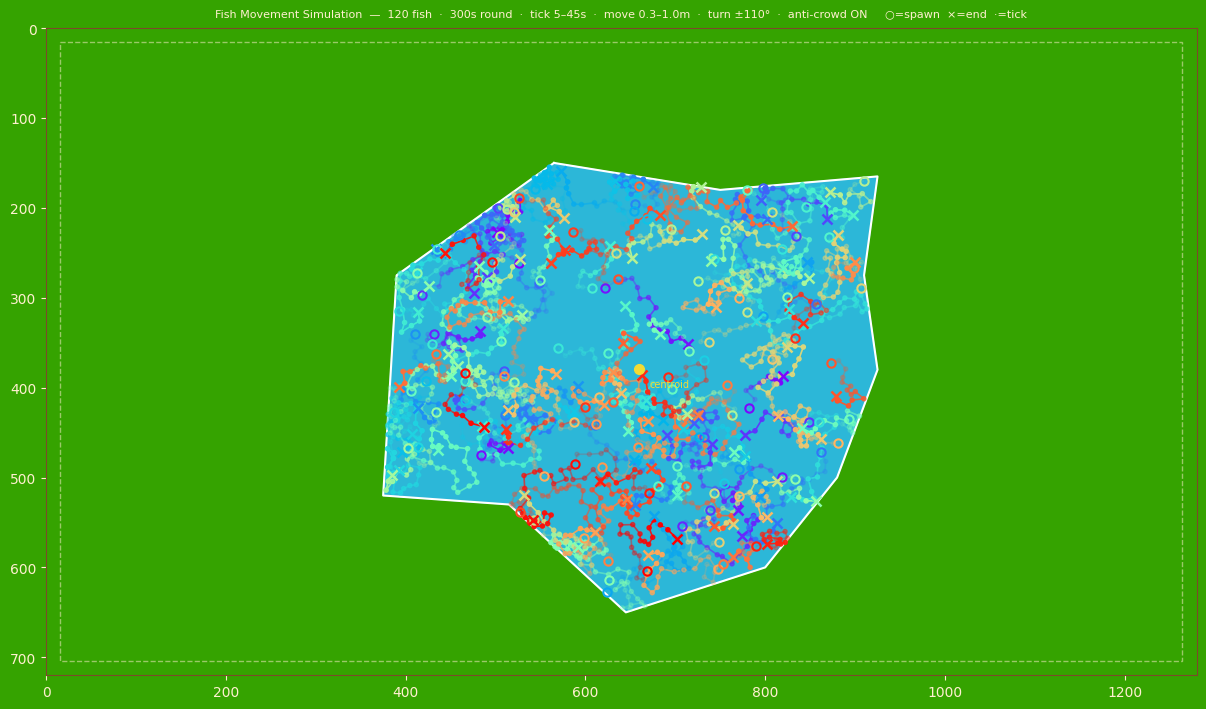

In [33]:
verts  = np.array(VERTICES, dtype=float)
closed = np.vstack([verts, verts[0]])
cx, cy = compute_centroid(VERTICES)

n_fish = len(fish_results)
cmap   = plt.colormaps["rainbow"].resampled(max(n_fish, 1))

fig, ax = plt.subplots(figsize=(12.8, 7.2), dpi=100)
fig.patch.set_facecolor("#35A300")  # grass green
ax.set_facecolor("#35A300")

ax.set_xlim(0, CANVAS_W)
ax.set_ylim(CANVAS_H, 0)            # flip y so (0,0) is top-left, matching Godot
ax.set_aspect("equal")

# Safe-zone margin
safe_rect = plt.Rectangle(
    (16, 16), CANVAS_W - 32, CANVAS_H - 32,
    linewidth=1, edgecolor="#FFF0D0", linestyle="--", facecolor="none", alpha=0.5,
)
ax.add_patch(safe_rect)

# Pond fill and outline
ax.fill(closed[:, 0], closed[:, 1], color="#2CB7D8", zorder=2)
ax.plot(closed[:, 0], closed[:, 1], color="#FFFFFF", linewidth=1.5, zorder=3)

# Fish paths
ALPHA_EARLY = 0.15   # alpha of the very first segment
ALPHA_LATE  = 1.0    # alpha of the very last segment

for f in fish_results:
    rgba    = cmap(f["id"] / max(n_fish - 1, 1))  # (r, g, b, a) from colormap
    r, g, b = rgba[0], rgba[1], rgba[2]
    path    = np.array(f["path"])
    n_segs  = len(path) - 1

    if n_segs >= 1:
        # Each segment: [[x0,y0], [x1,y1]]
        segments = np.stack([path[:-1], path[1:]], axis=1)
        alphas   = np.linspace(ALPHA_EARLY, ALPHA_LATE, n_segs)
        colors   = [(r, g, b, a) for a in alphas]
        lc = LineCollection(segments, colors=colors, linewidths=1.2, zorder=4)
        ax.add_collection(lc)

    # Intermediate tick dots — same alpha fade, skipping spawn and final
    if len(path) > 2:
        dot_pts    = path[1:-1]
        dot_alphas = np.linspace(ALPHA_EARLY, ALPHA_LATE, len(dot_pts))
        dot_colors = [(r, g, b, a) for a in dot_alphas]
        ax.scatter(dot_pts[:, 0], dot_pts[:, 1], c=dot_colors, s=9, zorder=5)

    # Spawn: open circle
    ax.plot(path[0, 0], path[0, 1], "o", color=(r, g, b), markersize=6,
            markerfacecolor="none", markeredgewidth=1.5, zorder=6)

    # Final position: X
    ax.plot(path[-1, 0], path[-1, 1], "x", color=(r, g, b), markersize=7,
            markeredgewidth=1.8, zorder=6)

# Centroid reference marker
ax.plot(cx, cy, "o", color="#F3DB34", markersize=7, zorder=7)
ax.annotate("centroid", xy=(cx, cy), xytext=(cx + 12, cy + 20),
            color="#F3DB34", fontsize=7, zorder=8)

title = (
    f"Fish Movement Simulation  —  {n_fish} fish  ·  {ROUND_DURATION_S}s round  ·  "
    f"tick {TICK_MIN_S}–{TICK_MAX_S}s  ·  move {MOVE_DIST_MIN_M}–{MOVE_DIST_MAX_M}m  ·  "
    f"turn ±{TURN_ANGLE_MAX_DEG}°  ·  "
    f"{'anti-crowd ON' if ENABLE_ANTICROWDING else 'anti-crowd OFF'}"
    f"     ○=spawn  ×=end  ·=tick"
)
ax.set_title(title, color="#FFF0D0", fontsize=8, pad=8)
ax.tick_params(colors="#FFF0D0")
for spine in ax.spines.values():
    spine.set_edgecolor("#7C4A2A")

plt.tight_layout()
plt.show()


## Movement Summary

Per-fish stats for the simulated round. Useful for checking whether tick intervals and
move distances produce a spread that feels right — e.g., a lazy fish (`Tick IV` near 45s)
should cover far less ground than an active one (`Tick IV` near 5s).


In [34]:
rows = []
for f in fish_results:
    n_moves = len(f["path"]) - 1
    path_px = (
        sum(math.dist(f["path"][i], f["path"][i + 1]) for i in range(n_moves))
        if n_moves else 0.0
    )
    disp_px = math.dist(f["path"][0], f["path"][-1]) if n_moves else 0.0
    rows.append({
        "Fish":             f["id"],
        "Tick IV (s)":      round(f["tick_iv"], 1),
        "Moves":            n_moves,
        "Total Dist (m)":   round(path_px / PIXELS_PER_METER, 1),
        "Displacement (m)": round(disp_px / PIXELS_PER_METER, 1),
    })

df_sum = pd.DataFrame(rows)
print(df_sum.to_string(index=False))
print()
print(f"  Avg moves per fish  : {df_sum['Moves'].mean():.1f}")
print(f"  Avg total dist      : {df_sum['Total Dist (m)'].mean():.1f} m")
print(f"  Avg displacement    : {df_sum['Displacement (m)'].mean():.1f} m")


 Fish  Tick IV (s)  Moves  Total Dist (m)  Displacement (m)
    0         13.9     22            16.5               2.8
    1         28.9     10             5.3               3.5
    2         29.9     10             5.6               2.0
    3         19.8     15            10.4               7.4
    4         20.7     15             9.4               4.0
    5         17.6     17            10.0               3.4
    6         12.0     25            15.4               4.5
    7         23.8     13             9.7               3.9
    8         19.7     15            10.2               4.8
    9         20.8     15             9.9               4.9
   10         20.6     14             9.0               5.2
   11         27.5     11             7.7               2.7
   12         25.6     12             8.0               2.7
   13         28.5     11             6.4               3.9
   14         26.9     12             8.1               0.8
   15         29.1     10             5.